In [1]:
import pandas as  pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("placement dataset.csv")
data

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [3]:
x = data[['cgpa']]
y = data[['package']]


In [4]:
x


,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [5]:
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


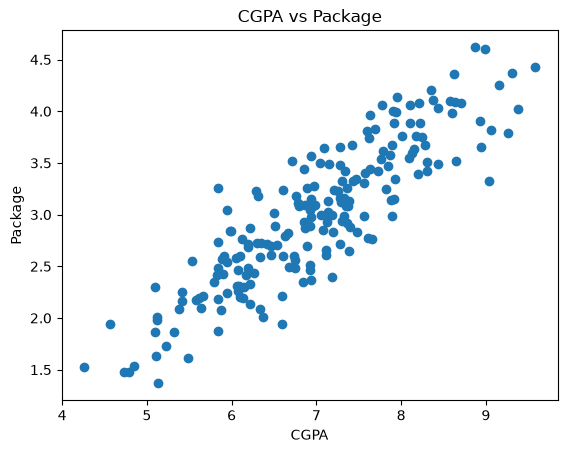

In [6]:
plt.title("CGPA vs Package")
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.scatter(x, y)

In [7]:
from sklearn.model_selection import train_test_split as tts

x_train, x_test, y_train, y_test = tts(x,y,test_size=0.2,random_state=42)

In [8]:
len(x_train), len(x_test)

(160, 40)

In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.57]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-1.03]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [10]:
y_pred = lr.predict(x_test)


In [11]:
y_test.values

array([[2.79],
       [3.23],
       [3.26],
       [3.04],
       [3.34],
       [4.21],
       [2.94],
       [2.87],
       [2.99],
       [3.58],
       [1.63],
       [2.08],
       [4.08],
       [2.21],
       [3.47],
       [3.64],
       [2.74],
       [3.08],
       [2.17],
       [2.99],
       [2.31],
       [2.35],
       [3.4 ],
       [3.08],
       [3.81],
       [2.19],
       [1.53],
       [2.89],
       [3.16],
       [2.48],
       [3.51],
       [2.98],
       [3.39],
       [3.28],
       [2.73],
       [3.74],
       [2.6 ],
       [3.13],
       [3.82],
       [3.15]])

In [12]:
m = lr.coef_
b = lr.intercept_

test = m*6.94 + b
test

array([[2.95833298]])

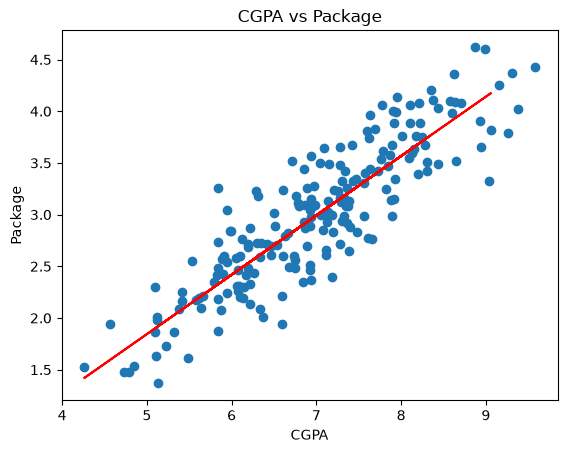

In [13]:
plt.title("CGPA vs Package")
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.scatter(x, y)
plt.plot(x_test, lr.predict(x_test),color='red')

In [14]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, y_pred))
print("r2 Score:", r2_score(y_test, y_pred))


Mean Absolute Error: 0.23150985393278373
Mean Squared Error: 0.08417638361329656
Root Mean Squared Error: 0.2901316659954521
r2 Score: 0.7730984312051673


In [15]:
r2 = r2_score(y_test, y_pred)

print("Adjusted r2 Score:", 1-(1-r2)*(len(y_test)-1)/(len(y_test) - 1 - x_test.shape[1]))

## Formula for Adjusted R2 Score = 1 - (1-R2)*(n-1)/(n-1-k)
## where n = number of observations, k = number of independent variables

Adjusted r2 Score: 0.7671273372895138


In [16]:
cgpa = float(input("Enter your CGPA: "))
x = lr.predict([[cgpa]])
print(f"Your predicted package is: {x}")

Your predicted package is: [[2.7378185]]


c:\Users\Rishabh_Jadav\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
